# Predictive Insight Engine
### Supervised Learning - House Price Prediction

## Part A: Conceptual Understanding

**1. What are Supervised Learning Algorithms?**
Algorithms trained on labeled data, where each input has a known correct output. The model learns the input-output mapping and uses it to predict outputs for new inputs.

**2. Regression vs Classification.**
Regression predicts a continuous numeric value. Classification predicts a discrete category.

**3. Simple Linear Regression.**
Models the relationship between one independent variable (X) and one dependent variable (Y) as a straight line: Y = mX + c.

**4. Assumptions of Linear Regression.**
Linearity, independence of errors, homoscedasticity (constant error variance), normality of residuals, no multicollinearity.

**5. Bias-Variance Trade-Off.**
Bias = error from an overly simple model (underfitting). Variance = error from a model too sensitive to training data (overfitting). Lower one usually raises the other.

**6. Overfitting and Underfitting.**
Overfitting: model fits training data (and its noise) too closely, performs poorly on new data. Underfitting: model is too simple to capture the pattern, performs poorly even on training data.

## Part B: Dataset Understanding & Preparation

In [20]:
import pandas as pd

df = pd.read_csv('realestate_houseprice_dataset_.csv')
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


Independent variables: area_sqft, bedrooms, bathrooms, location_score, age_years, distance_city_km, lot_size_sqft, has_garage, has_pool, renovation_years_ago.
Dependent variable: house_price_inr.

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB


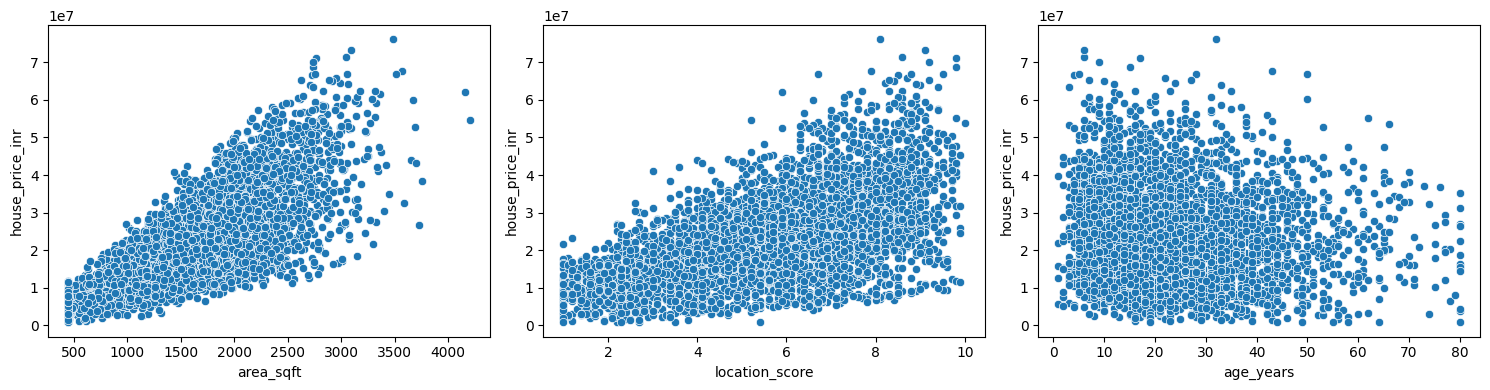

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=df, x='area_sqft', y='house_price_inr', ax=axes[0])
sns.scatterplot(data=df, x='location_score', y='house_price_inr', ax=axes[1])
sns.scatterplot(data=df, x='age_years', y='house_price_inr', ax=axes[2])
plt.tight_layout()
plt.show()

Area shows the clearest upward trend with price - bigger houses cost more, fairly linearly. Location score also trends upward but with more spread, meaning location alone doesn't fix price. Age shows almost no visible trend, so it likely won't be a strong predictor on its own.

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['house_id', 'house_price_inr'])
y = df['house_price_inr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((3360, 10), (840, 10))

## Part C: Simple Linear Regression

In [24]:
from sklearn.linear_model import LinearRegression

X_train_simple = X_train[['area_sqft']]
X_test_simple = X_test[['area_sqft']]

lr_simple = LinearRegression()
lr_simple.fit(X_train_simple, y_train)

y_pred_simple = lr_simple.predict(X_test_simple)
print('slope:', lr_simple.coef_[0])
print('intercept:', lr_simple.intercept_)

slope: 14788.306111307536
intercept: -1163519.1764186025


Slope shows how much house price changes per sq.ft increase in area. Intercept is the price when area is zero (not meaningful alone, just the line's baseline).

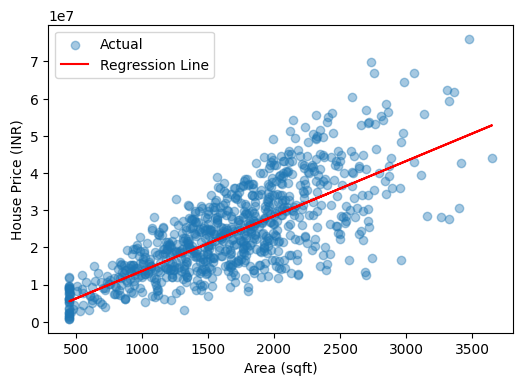

In [25]:
plt.figure(figsize=(6, 4))
plt.scatter(X_test_simple, y_test, alpha=0.4, label='Actual')
plt.plot(X_test_simple, y_pred_simple, color='red', label='Regression Line')
plt.xlabel('Area (sqft)')
plt.ylabel('House Price (INR)')
plt.legend()
plt.show()

The red line tracks the upward trend of the actual points reasonably well, but the scatter is wide around it - area alone explains price direction, not the exact value, which lines up with the moderate R2 we'll see in Part D.

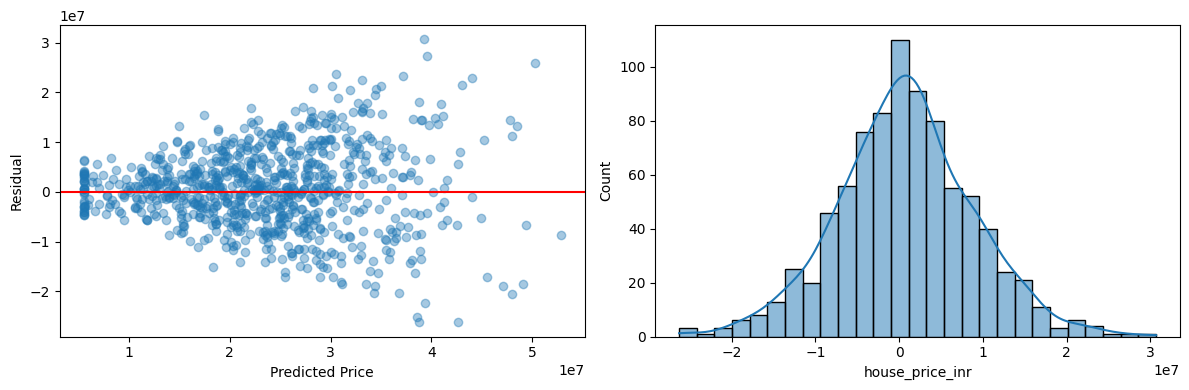

In [26]:
residuals = y_test - y_pred_simple

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred_simple, residuals, alpha=0.4)
axes[0].axhline(0, color='red')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual')
sns.histplot(residuals, kde=True, ax=axes[1])
plt.tight_layout()
plt.show()

Residuals scatter around zero with no clear pattern, and the histogram is roughly bell-shaped - this supports the linearity and normality assumptions.

## Part D: Model Evaluation Metrics

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

mae_simple = mean_absolute_error(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, y_pred_simple)
adj_r2_simple = adjusted_r2(r2_simple, len(y_test), 1)

print('MAE:', mae_simple)
print('MSE:', mse_simple)
print('RMSE:', rmse_simple)
print('R2:', r2_simple)
print('Adjusted R2:', adj_r2_simple)

MAE: 6294593.696131912
MSE: 66989260021849.47
RMSE: 8184696.696997969
R2: 0.5625199587991578
Adjusted R2: 0.5619979062440257


MAE and RMSE are in INR, showing average prediction error size. R2 shows the fraction of price variation explained by area alone. Adjusted R2 penalizes for feature count, which matters more once more features are added.

## Part E: Multiple Linear Regression

In [28]:
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

y_pred_multi = lr_multi.predict(X_test)

mae_multi = mean_absolute_error(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, y_pred_multi)
adj_r2_multi = adjusted_r2(r2_multi, len(y_test), X_train.shape[1])

pd.DataFrame(lr_multi.coef_, index=X_train.columns, columns=['Coefficient'])

,Coefficient
area_sqft,1.379594e+04
bedrooms,1.976431e+05
bathrooms,1.859445e+05
location_score,3.073174e+06
age_years,-6.560924e+04
distance_city_km,-9.896516e+04
lot_size_sqft,1.035058e+02
has_garage,9.392436e+04
has_pool,4.552902e+05
renovation_years_ago,-2.143591e+04


In [29]:
compare_df = pd.DataFrame({
    'Model': ['Simple Linear', 'Multiple Linear'],
    'MAE': [mae_simple, mae_multi],
    'RMSE': [rmse_simple, rmse_multi],
    'R2': [r2_simple, r2_multi],
    'Adjusted R2': [adj_r2_simple, adj_r2_multi]
})
compare_df

,Model,MAE,RMSE,R2,Adjusted R2
0,Simple Linear,6.294594e+06,8.184697e+06,0.562520,0.561998
1,Multiple Linear,2.604991e+06,3.548650e+06,0.917761,0.916769


Multiple regression scores better on every metric - area alone misses price drivers like location_score, bathrooms and has_pool, which the multi-feature model can now account for.

## Part F: Polynomial Regression

In [30]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_simple)
X_test_poly = poly.transform(X_test_simple)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

y_pred_poly = lr_poly.predict(X_test_poly)

r2_poly_train = r2_score(y_train, lr_poly.predict(X_train_poly))
r2_poly_test = r2_score(y_test, y_pred_poly)
print('train R2:', r2_poly_train)
print('test R2:', r2_poly_test)

train R2: 0.5724674245504779
test R2: 0.5626917978136475


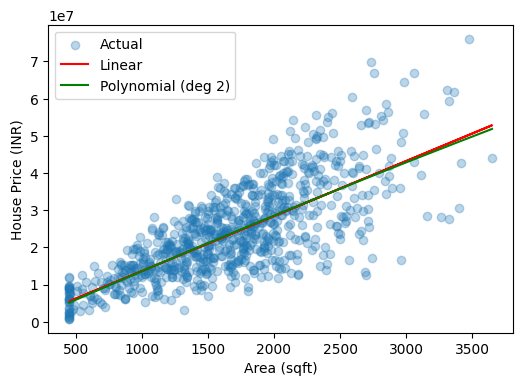

In [31]:
sort_idx = X_test_simple['area_sqft'].argsort()
area_sorted = X_test_simple['area_sqft'].values[sort_idx]

plt.figure(figsize=(6, 4))
plt.scatter(X_test_simple, y_test, alpha=0.3, label='Actual')
plt.plot(X_test_simple, y_pred_simple, color='red', label='Linear')
plt.plot(area_sorted, y_pred_poly[sort_idx], color='green', label='Polynomial (deg 2)')
plt.xlabel('Area (sqft)')
plt.ylabel('House Price (INR)')
plt.legend()
plt.show()

Train R2 and test R2 for the polynomial model are close to each other and close to the simple linear model's R2 - so on this single feature, degree 2 doesn't overfit, but it also barely improves over the straight line, since area vs price here is close to linear.

## Part G: Bias-Variance & Model Diagnostics

In [ ]:
r2_simple_train = r2_score(y_train, lr_simple.predict(X_train_simple))
r2_multi_train = r2_score(y_train, lr_multi.predict(X_train))

diagnostics_df = pd.DataFrame({
    'Model': ['Simple Linear', 'Multiple Linear', 'Polynomial (deg 2)'],
    'Train R2': [r2_simple_train, r2_multi_train, r2_poly_train],
    'Test R2': [r2_simple, r2_multi, r2_poly_test]
})
diagnostics_df['Gap'] = diagnostics_df['Train R2'] - diagnostics_df['Test R2']
diagnostics_df

,Model,Train R2,Test R2,Gap
0,Simple Linear,0.572307,0.562520,0.009788
1,Multiple Linear,0.924722,0.917761,0.006961
2,Polynomial (deg 2),0.572467,0.562692,0.009776


A high train R2 with a low test R2 (a big gap) signals high variance / overfitting. A low train R2 for both signals high bias / underfitting. Here Simple Linear has the most bias (lowest R2 overall), while Multiple Linear has the smallest gap along with the highest scores - it balances bias and variance best on this dataset.

## Part H: Final Analysis & Reporting



**Best-performing model:** Multiple Linear Regression - highest R2/Adjusted R2 and lowest error of the three models, since it uses all relevant features instead of area alone.

**Impact of gradient descent:** All three variants (Batch, SGD, Mini-Batch) converge to essentially the same slope/intercept as sklearn's closed-form solution, confirming the optimization is correct; they differ mainly in convergence smoothness and speed.

**Overfitting/underfitting evidence:** Simple Linear underfits (lowest R2, high bias). Polynomial (deg 2) on a single feature neither overfits nor adds much value here, since train and test R2 stay close together. Multiple Linear generalizes best (smallest train-test gap).

**Business interpretation:** Price is driven by more than size alone - location, bathrooms and amenities like a pool meaningfully move predicted price, so a pricing tool for this firm should use the full feature set (Multiple Linear Regression) rather than area-only estimates.